# 🌿 22km Plant Traits Project — Data Inspection

Understanding the structure, content, and statistical properties of all input data sources before any preprocessing.

## Data sources overview

| Folder | Type | Description | Status |
|--------|------|-------------|--------|
| `gbif/` | TIF (31 files) | GBIF plant trait maps, 1 per trait | Pre-transformed & normalised |
| `splot/` | TIF (31 files) | sPlot plant trait maps, 1 per trait | Pre-transformed & normalised |
| `skcv_splits/` | Parquet (31 files) | Spatial cross-validation splits | Validation files |
| `eo_data/canopy_height/` | TIF (1 file) | Global canopy height map | Needs transform/normalise |
| `eo_data/modis/` | TIF (72 files) | MODIS bands 1–5 + NDVI × 12 months | Needs transform/normalise |
| `eo_data/soil_grids/` | TIF (61 files) | Soil properties at multiple depths | Needs transform/normalise |
| `eo_data/vodca/` | TIF (9 files) | Vegetation optical depth (C/K/X bands, mean/p5/p95) | Needs transform/normalise |
| `eo_data/worldclim/` | TIF (6 files) | WorldClim 2.1 bioclimatic variables | Needs transform/normalise |
| `power_transform_params.csv` | CSV | Parameters used to transform GBIF & sPlot | Used to reverse-transform |

---

## 0. Imports & Setup

In [1]:
import os
import glob
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rasterio

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "font.family": "sans-serif",
    }
)
sns.set_style("whitegrid")

print("✅ All imports successful")

✅ All imports successful


In [2]:
# ── Root path ─────────────────────────────
ROOT = "/scratch3/plant-traits-v2/data"

PATHS = {
    "gbif": os.path.join(ROOT, "22km", "gbif"),
    "splot": os.path.join(ROOT, "22km", "splot"),
    "skcv": os.path.join(ROOT, "22km", "skcv_splits"),
    "canopy": os.path.join(ROOT, "22km", "eo_data", "canopy_height"),
    "modis": os.path.join(ROOT, "22km", "eo_data", "modis"),
    "soil": os.path.join(ROOT, "22km", "eo_data", "soilgrids"),
    "vodca": os.path.join(ROOT, "22km", "eo_data", "vodca"),
    "worldclim": os.path.join(ROOT, "22km", "eo_data", "worldclim"),
    "transform_csv": os.path.join(ROOT, "power_transformer_params.csv"),
}

# Quick sanity check
for name, path in PATHS.items():
    exists = os.path.exists(path)
    print(f"{'✅' if exists else '❌'}  {name:20s}  {path}")

✅  gbif                  /scratch3/plant-traits-v2/data/22km/gbif
✅  splot                 /scratch3/plant-traits-v2/data/22km/splot
✅  skcv                  /scratch3/plant-traits-v2/data/22km/skcv_splits
✅  canopy                /scratch3/plant-traits-v2/data/22km/eo_data/canopy_height
✅  modis                 /scratch3/plant-traits-v2/data/22km/eo_data/modis
✅  soil                  /scratch3/plant-traits-v2/data/22km/eo_data/soilgrids
✅  vodca                 /scratch3/plant-traits-v2/data/22km/eo_data/vodca
✅  worldclim             /scratch3/plant-traits-v2/data/22km/eo_data/worldclim
✅  transform_csv         /scratch3/plant-traits-v2/data/power_transformer_params.csv


---
## 1. Helper Functions

In [3]:
def tif_summary(filepath):
    """Return a dict with key metadata and stats for a single TIF file."""
    with rasterio.open(filepath) as src:
        meta = {
            "file": os.path.basename(filepath),
            "width": src.width,
            "height": src.height,
            "bands": src.count,
            "crs": str(src.crs),
            "dtype": src.dtypes[0],
            "nodata": src.nodata,
            "transform": src.transform,
            "bounds": src.bounds,
        }
        data = src.read(1).astype(np.float32)
        nodata = src.nodata
        mask = (
            (data == nodata) if nodata is not None else np.zeros_like(data, dtype=bool)
        )
        valid = data[~mask]
        meta.update(
            {
                "n_valid": int(valid.size),
                "n_nodata": int(mask.sum()),
                "min": float(np.nanmin(valid)) if valid.size else np.nan,
                "max": float(np.nanmax(valid)) if valid.size else np.nan,
                "mean": float(np.nanmean(valid)) if valid.size else np.nan,
                "std": float(np.nanstd(valid)) if valid.size else np.nan,
                "p1": float(np.nanpercentile(valid, 1)) if valid.size else np.nan,
                "p99": float(np.nanpercentile(valid, 99)) if valid.size else np.nan,
            }
        )
    return meta


def plot_tif(filepath, title=None, cmap="viridis", percentile_clip=(2, 98)):
    """Plot spatial map + histogram side by side for a TIF file."""
    with rasterio.open(filepath) as src:
        data = src.read(1).astype(np.float32)
        nodata = src.nodata
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    mask = (data == nodata) if nodata is not None else np.zeros_like(data, dtype=bool)
    data[mask] = np.nan
    valid = data[~np.isnan(data)]

    vmin, vmax = np.nanpercentile(valid, percentile_clip)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    title = title or os.path.basename(filepath)
    fig.suptitle(title, fontsize=12, fontweight="bold")

    # Spatial map
    im = axes[0].imshow(
        data, cmap=cmap, vmin=vmin, vmax=vmax, extent=extent, aspect="auto"
    )
    plt.colorbar(im, ax=axes[0], fraction=0.03)
    axes[0].set_title("Spatial map")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")

    # Histogram
    axes[1].hist(valid, bins=100, color="steelblue", edgecolor="none", alpha=0.8)
    axes[1].axvline(
        np.nanmean(valid),
        color="red",
        ls="--",
        lw=1.5,
        label=f"mean={np.nanmean(valid):.3f}",
    )
    axes[1].axvline(
        np.nanmedian(valid),
        color="orange",
        ls="--",
        lw=1.5,
        label=f"median={np.nanmedian(valid):.3f}",
    )
    axes[1].set_title("Value distribution")
    axes[1].set_xlabel("Value")
    axes[1].set_ylabel("Count")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    print(
        f"  Shape: {data.shape} | Valid px: {valid.size:,} | "
        f"Min: {valid.min():.4f} | Max: {valid.max():.4f} | "
        f"Mean: {valid.mean():.4f} | Std: {valid.std():.4f}"
    )


def summarise_folder(folder, pattern="*.tif"):
    """Return a DataFrame with stats for every TIF in a folder."""
    files = sorted(glob.glob(os.path.join(folder, "**", pattern), recursive=True))
    print(f"Found {len(files)} files in {os.path.basename(folder)}")
    rows = [tif_summary(f) for f in files]
    return pd.DataFrame(rows)


print("✅ Helper functions defined")

✅ Helper functions defined


---
## 2. Transformation Parameters CSV

It tells us how GBIF and sPlot were transformed, and we'll need it to reverse the transformation later.

In [4]:
transform_df = pd.read_csv(PATHS["transform_csv"])
print(f"Shape: {transform_df.shape}")
print(f"Columns: {transform_df.columns.tolist()}")
transform_df.head(10)

Shape: (32, 4)
Columns: ['trait', 'yeo_johnson_lambda', 'standardize_mean', 'standardize_scale']


,trait,yeo_johnson_lambda,standardize_mean,standardize_scale
0,X3117,0.135641,3.292038,0.675721
1,X14,0.294290,4.951056,0.780634
2,X50,-0.696778,0.675542,0.119878
3,X146,-0.407898,1.791778,0.089878
4,X3120,-0.498594,1.032026,0.170561
5,X297,0.077208,2.608437,0.539573
6,X21,-10.148966,0.038466,0.028456
7,X13,1.410638,4036.621787,341.106533
8,X15,-0.387341,0.724772,0.195989
9,X3113,0.086908,9.705253,2.842830


In [5]:
# Descriptive stats of the parameter columns
transform_df.describe()

,yeo_johnson_lambda,standardize_mean,standardize_scale
count,32.000000,32.000000,32.000000
mean,-0.752638,30443.260126,9525.828561
std,2.584354,171462.072610,53820.042278
min,-10.148966,0.038466,0.002916
25%,-0.430572,0.712464,0.171191
50%,-0.153827,2.200107,0.523178
75%,0.084739,4.966065,0.952087
max,3.340212,970060.598434,304463.650046


---
## 3. GBIF Plant Trait Maps

In [6]:
gbif_files = sorted(glob.glob(os.path.join(PATHS["gbif"], "*.tif")))
print(f"GBIF TIF files found: {len(gbif_files)}")
for f in gbif_files:
    print(f"  {os.path.basename(f)}")

GBIF TIF files found: 37
  X1080.tif
  X13.tif
  X138.tif
  X14.tif
  X144.tif
  X145.tif
  X146.tif
  X15.tif
  X163.tif
  X169.tif
  X21.tif
  X223.tif
  X224.tif
  X237.tif
  X26.tif
  X27.tif
  X281.tif
  X282.tif
  X289.tif
  X297.tif
  X3106.tif
  X3107.tif
  X3112.tif
  X3113.tif
  X3114.tif
  X3117.tif
  X3120.tif
  X351.tif
  X4.tif
  X46.tif
  X47.tif
  X50.tif
  X55.tif
  X6.tif
  X614.tif
  X78.tif
  X95.tif


In [7]:
# Summary stats table for all 31 GBIF trait files
gbif_summary = summarise_folder(PATHS["gbif"])
gbif_summary[
    [
        "file",
        "width",
        "height",
        "crs",
        "dtype",
        "nodata",
        "n_valid",
        "n_nodata",
        "min",
        "max",
        "mean",
        "std",
    ]
]

Found 37 files in gbif


,file,width,height,crs,dtype,nodata,n_valid,n_nodata,min,max,mean,std
0,X1080.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-4.063695,3.570292,0.149079,0.471407
1,X13.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-3.517963,3.193609,-0.244858,0.484105
2,X138.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-2.531411,3.872839,0.128058,0.441226
3,X14.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-2.499343,3.383331,0.295306,0.470243
4,X144.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-2.716864,2.958215,-0.131093,0.449154
5,X145.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-1.848406,3.068238,-0.173138,0.544912
6,X146.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-4.016565,2.376236,-0.302295,0.470570
7,X15.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-2.021972,3.674224,0.382163,0.527199
8,X163.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-1.396779,2.073150,-0.171207,0.573897
9,X169.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-2.489829,2.954608,0.166616,0.590019


Inspecting: X1080.tif


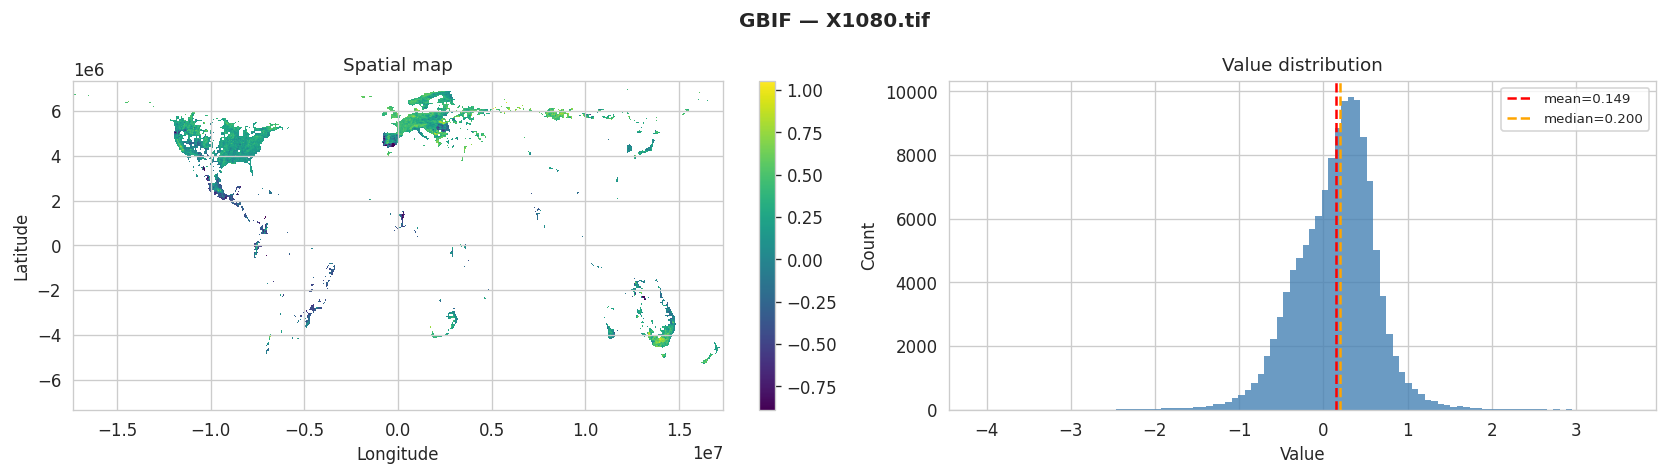

  Shape: (668, 1578) | Valid px: 127,236 | Min: -4.0637 | Max: 3.5703 | Mean: 0.1491 | Std: 0.4714


In [40]:
# ── Inspect ONE example GBIF trait in detail ────────────────────────────────
# (Values should look normalised: roughly mean≈0, std≈1 if z-scored)
example_gbif = gbif_files[0]
print(f"Inspecting: {os.path.basename(example_gbif)}")
plot_tif(example_gbif, title=f"GBIF — {os.path.basename(example_gbif)}")

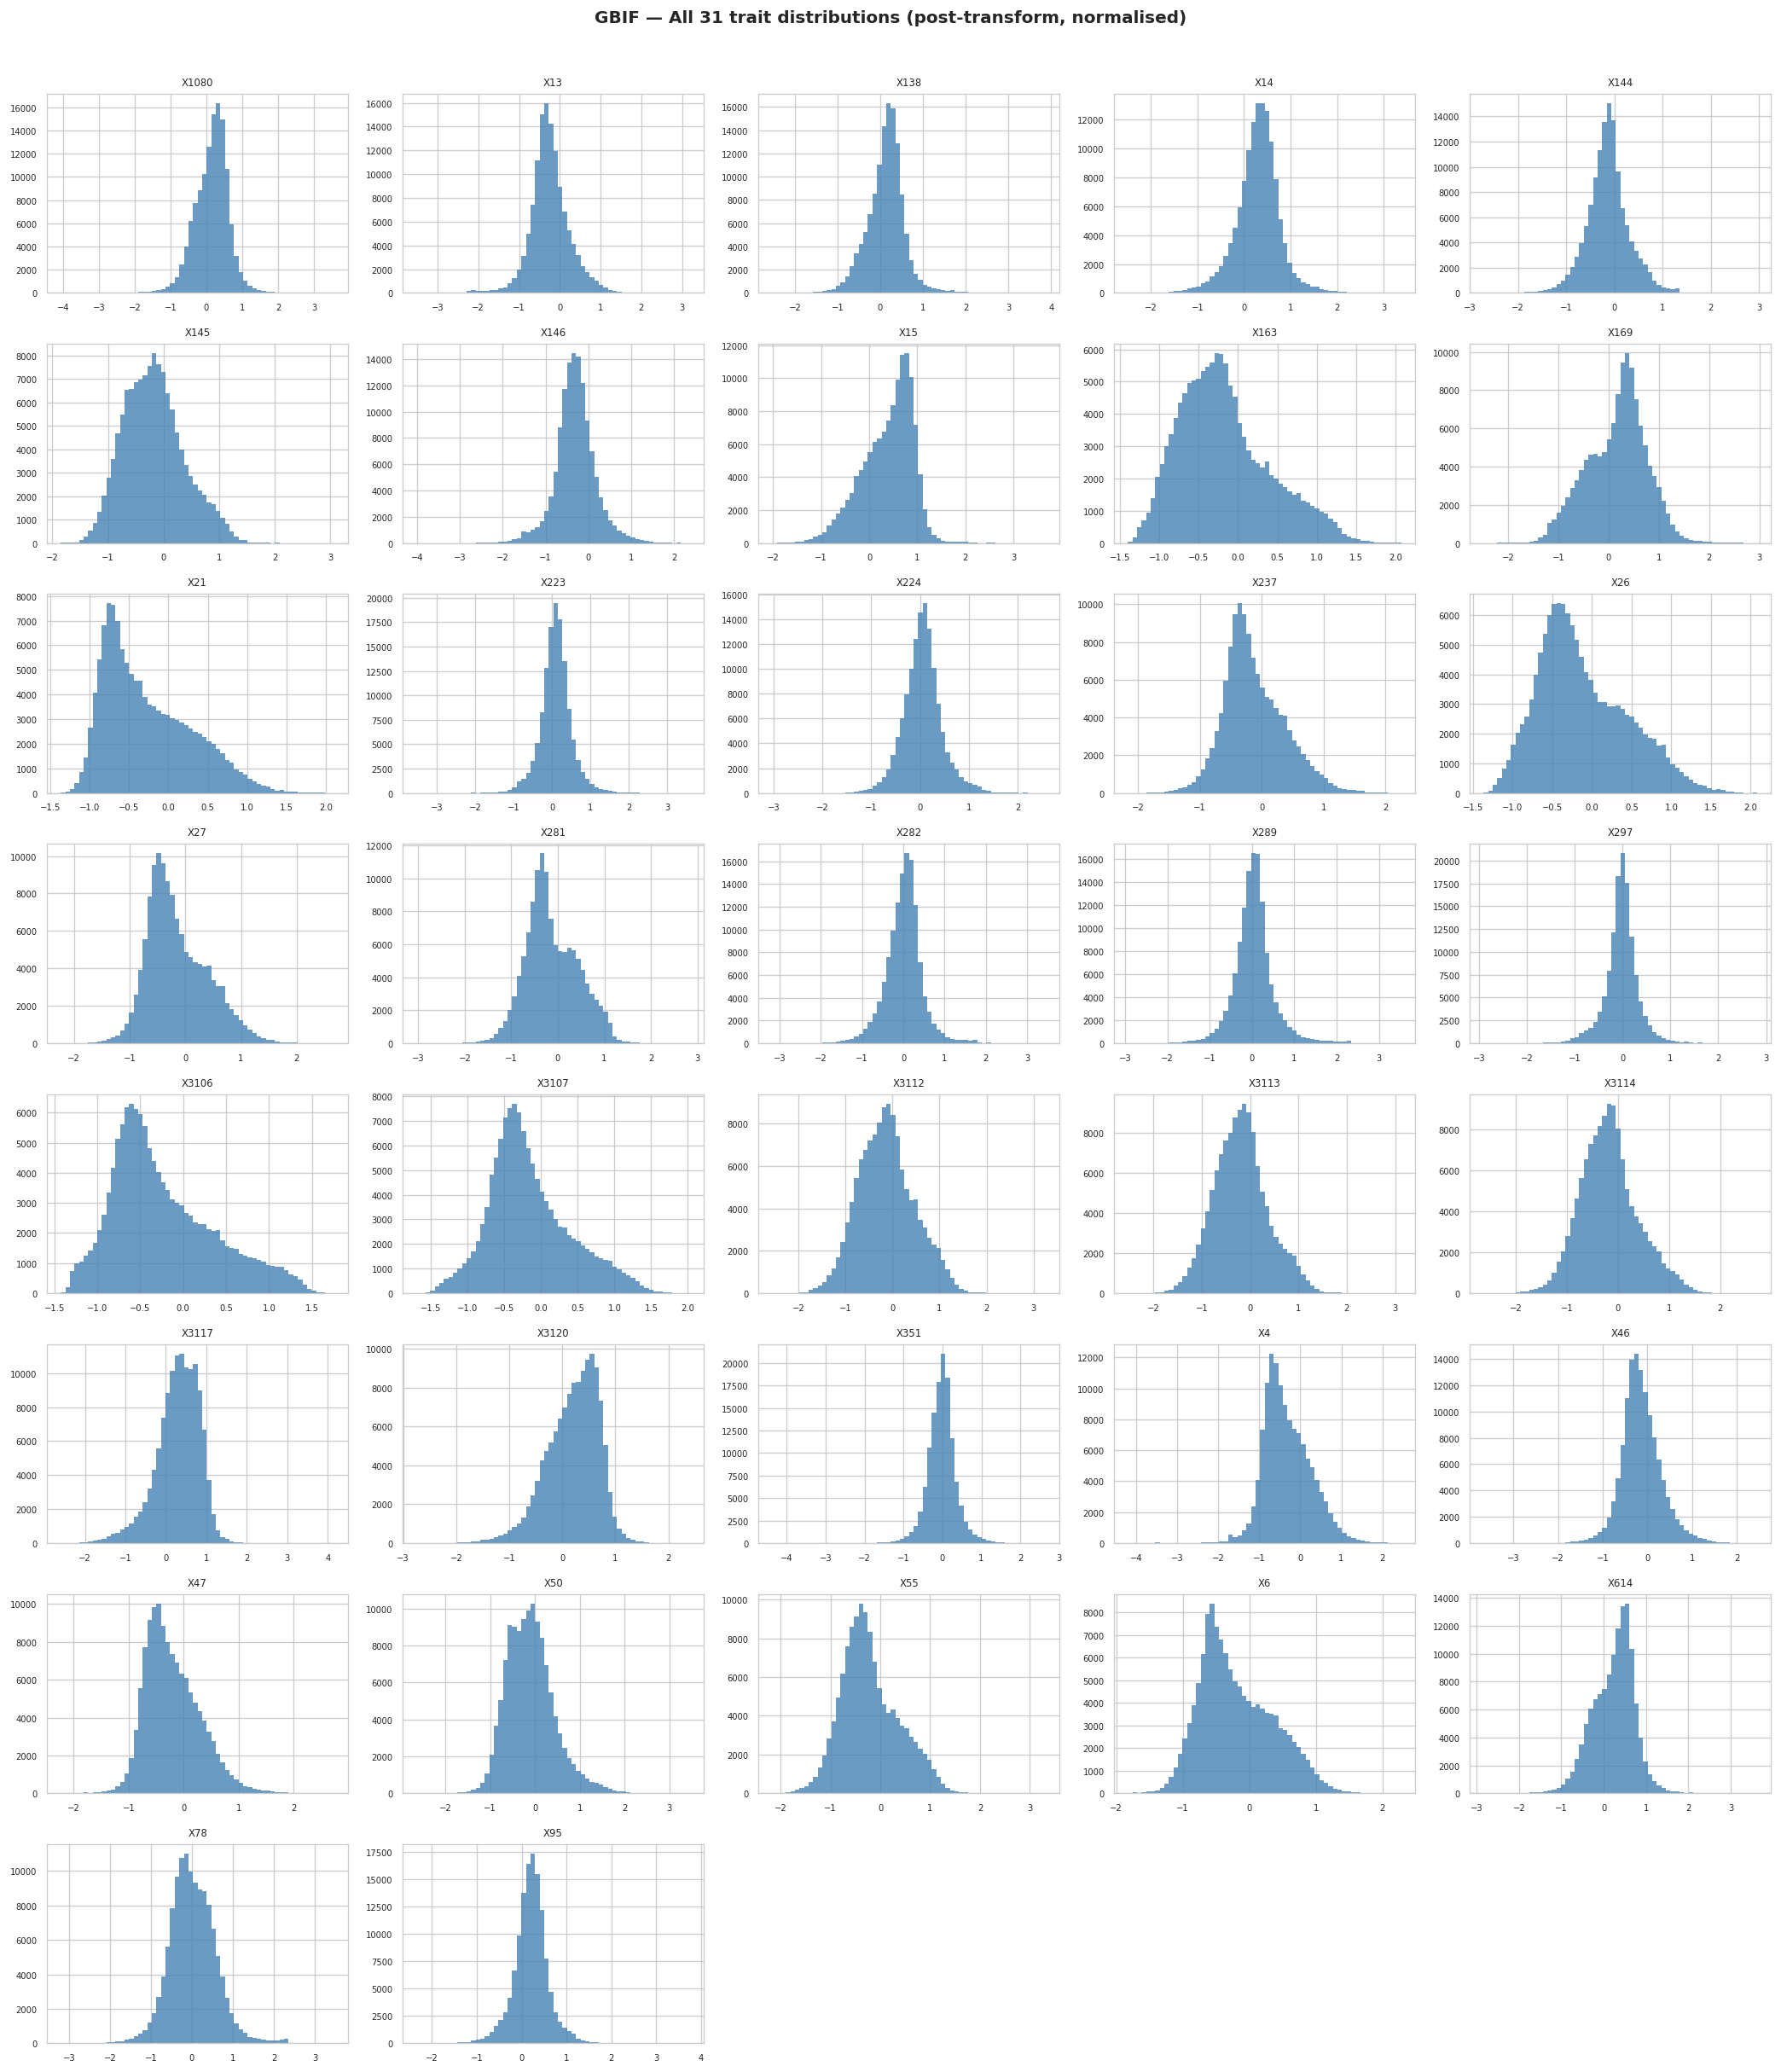

In [9]:
# ── Distribution overview: all 31 GBIF traits in one figure ─────────────────
n = len(gbif_files)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.5))
axes = axes.flatten()

for i, fpath in enumerate(gbif_files):
    with rasterio.open(fpath) as src:
        data = src.read(1).astype(np.float32)
        nd = src.nodata
    if nd is not None:
        data[data == nd] = np.nan
    valid = data[~np.isnan(data)]
    axes[i].hist(valid, bins=60, color="steelblue", edgecolor="none", alpha=0.8)
    axes[i].set_title(os.path.basename(fpath).replace(".tif", ""), fontsize=7)
    axes[i].tick_params(labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "GBIF — All 31 trait distributions (post-transform, normalised)",
    fontsize=12,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

---
## 4. sPlot Plant Trait Maps

In [10]:
splot_files = sorted(glob.glob(os.path.join(PATHS["splot"], "*.tif")))
print(f"sPlot TIF files found: {len(splot_files)}")
for f in splot_files:
    print(f"  {os.path.basename(f)}")

sPlot TIF files found: 37
  X1080.tif
  X13.tif
  X138.tif
  X14.tif
  X144.tif
  X145.tif
  X146.tif
  X15.tif
  X163.tif
  X169.tif
  X21.tif
  X223.tif
  X224.tif
  X237.tif
  X26.tif
  X27.tif
  X281.tif
  X282.tif
  X289.tif
  X297.tif
  X3106.tif
  X3107.tif
  X3112.tif
  X3113.tif
  X3114.tif
  X3117.tif
  X3120.tif
  X351.tif
  X4.tif
  X46.tif
  X47.tif
  X50.tif
  X55.tif
  X6.tif
  X614.tif
  X78.tif
  X95.tif


In [11]:
splot_summary = summarise_folder(PATHS["splot"])
splot_summary[
    [
        "file",
        "width",
        "height",
        "crs",
        "dtype",
        "nodata",
        "n_valid",
        "n_nodata",
        "min",
        "max",
        "mean",
        "std",
    ]
]

Found 37 files in splot


,file,width,height,crs,dtype,nodata,n_valid,n_nodata,min,max,mean,std
0,X1080.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-3.521580,4.575099,-0.006882,0.809296
1,X13.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-3.555455,3.278876,0.091890,0.809835
2,X138.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-2.564925,3.872839,0.389044,0.733157
3,X14.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-2.958051,3.469370,-0.092832,0.662259
4,X144.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-3.676283,2.844097,-0.308446,0.543112
5,X145.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-1.884122,2.316725,-0.534462,0.669438
6,X146.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-3.803033,2.702385,0.046280,0.700496
7,X15.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-2.564458,2.854496,0.303604,0.575609
8,X163.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-1.398431,2.103416,-0.472447,0.528702
9,X169.tif,1578,668,EPSG:6933,float64,NaN,1054104,0,-2.720089,3.150488,0.801549,0.728810


Inspecting: X1080.tif


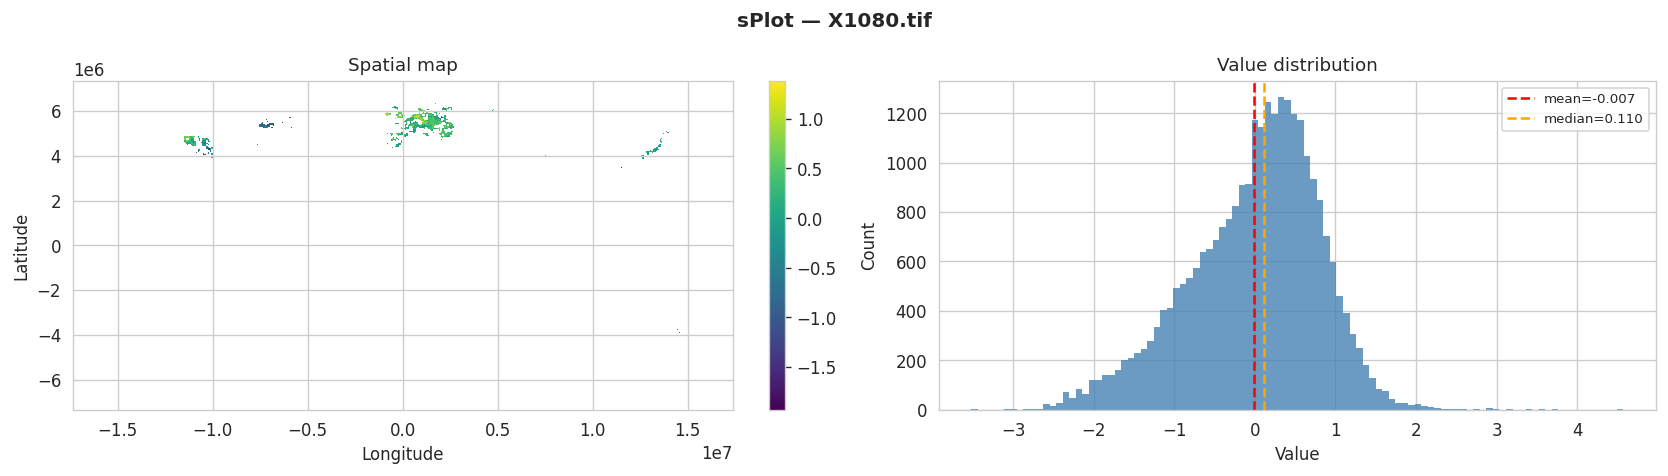

  Shape: (668, 1578) | Valid px: 27,413 | Min: -3.5216 | Max: 4.5751 | Mean: -0.0069 | Std: 0.8093


In [12]:
# Inspect one sPlot example
example_splot = splot_files[0]
print(f"Inspecting: {os.path.basename(example_splot)}")
plot_tif(example_splot, title=f"sPlot — {os.path.basename(example_splot)}")

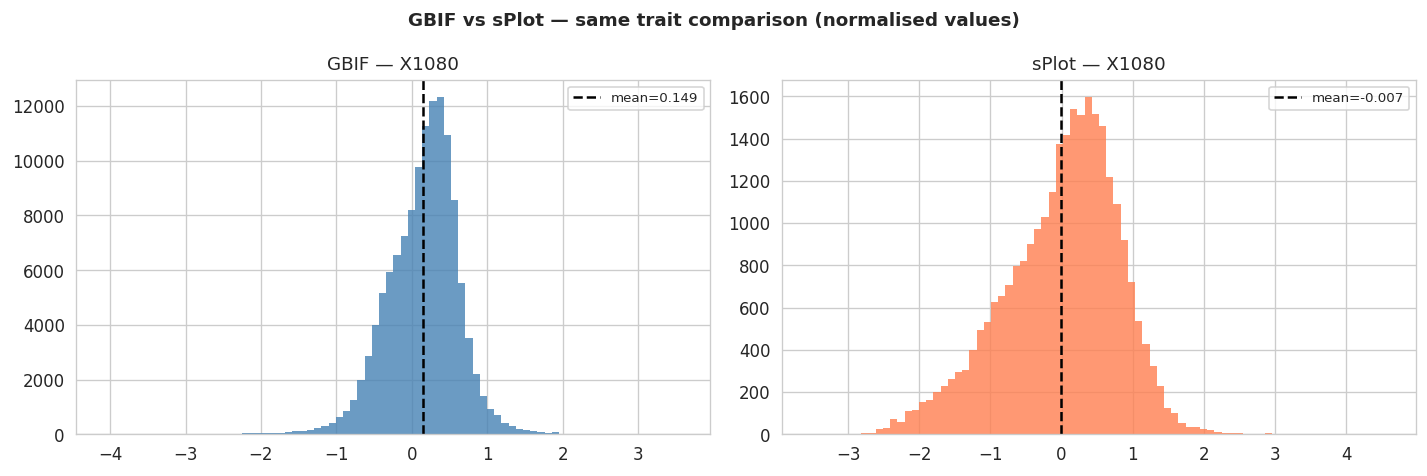

In [13]:
# ── Compare GBIF vs sPlot for the SAME trait (first trait) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    "GBIF vs sPlot — same trait comparison (normalised values)",
    fontsize=11,
    fontweight="bold",
)

for ax, fpath, label, color in zip(
    axes, [gbif_files[0], splot_files[0]], ["GBIF", "sPlot"], ["steelblue", "coral"]
):
    with rasterio.open(fpath) as src:
        data = src.read(1).astype(np.float32)
        nd = src.nodata
    if nd is not None:
        data[data == nd] = np.nan
    valid = data[~np.isnan(data)]
    ax.hist(valid, bins=80, color=color, edgecolor="none", alpha=0.8)
    ax.axvline(
        np.nanmean(valid),
        color="black",
        ls="--",
        lw=1.5,
        label=f"mean={np.nanmean(valid):.3f}",
    )
    ax.set_title(f"{label} — {os.path.basename(fpath).replace('.tif', '')}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 5. skcv_splits — Spatial Cross-Validation Splits

These parquet files encode which pixels/samples belong to which fold of a **spatial k-fold cross-validation** — a method used to avoid spatial autocorrelation leakage between train and test sets.

In [14]:
skcv_files = sorted(glob.glob(os.path.join(PATHS["skcv"], "*.parquet")))
print(f"skcv_splits parquet files found: {len(skcv_files)}")
for f in skcv_files:
    print(f"  {os.path.basename(f)}")

skcv_splits parquet files found: 37
  X1080_mean.parquet
  X138_mean.parquet
  X13_mean.parquet
  X144_mean.parquet
  X145_mean.parquet
  X146_mean.parquet
  X14_mean.parquet
  X15_mean.parquet
  X163_mean.parquet
  X169_mean.parquet
  X21_mean.parquet
  X223_mean.parquet
  X224_mean.parquet
  X237_mean.parquet
  X26_mean.parquet
  X27_mean.parquet
  X281_mean.parquet
  X282_mean.parquet
  X289_mean.parquet
  X297_mean.parquet
  X3106_mean.parquet
  X3107_mean.parquet
  X3112_mean.parquet
  X3113_mean.parquet
  X3114_mean.parquet
  X3117_mean.parquet
  X3120_mean.parquet
  X351_mean.parquet
  X46_mean.parquet
  X47_mean.parquet
  X4_mean.parquet
  X50_mean.parquet
  X55_mean.parquet
  X614_mean.parquet
  X6_mean.parquet
  X78_mean.parquet
  X95_mean.parquet


In [15]:
# ── Load ONE parquet file and inspect structure ──────────────────────────────
example_parquet = skcv_files[0]
df_skcv = pd.read_parquet(example_parquet)

print(f"File: {os.path.basename(example_parquet)}")
print(f"Shape: {df_skcv.shape}")
print(f"\nColumn names:\n{df_skcv.columns.tolist()}")
print(f"\nDtypes:\n{df_skcv.dtypes}")
print("\nFirst 5 rows:")
df_skcv.head()

File: X1080_mean.parquet
Shape: (130527, 3)

Column names:
['x', 'y', 'fold']

Dtypes:
x       float64
y       float64
fold      int64
dtype: object

First 5 rows:


,x,y,fold
0,-1.735652e+07,6.957519e+06,3
1,-1.735652e+07,6.935536e+06,3
2,-1.735652e+07,6.847605e+06,3
3,-1.735652e+07,6.825622e+06,3
4,-1.735652e+07,6.781657e+06,3


In [16]:
# ── Understand what columns look like ───────────────────────────────────────
df_skcv.describe(include="all")

,x,y,fold
count,1.305270e+05,1.305270e+05,130527.000000
mean,8.818602e+05,2.473658e+06,1.912240
std,8.488938e+06,3.528672e+06,1.340135
min,-1.735652e+07,-6.803640e+06,0.000000
25%,-7.076883e+06,-6.045237e+05,1.000000
50%,1.507827e+06,3.857961e+06,2.000000
75%,8.243524e+06,5.484679e+06,3.000000
max,1.735652e+07,7.287259e+06,4.000000


In [17]:
# Check for fold/split columns (common names)
fold_cols = [
    c
    for c in df_skcv.columns
    if any(k in c.lower() for k in ["fold", "split", "train", "test", "val", "cv"])
]
print(f"Potential fold/split columns: {fold_cols}")

# Check value counts for those columns
for col in fold_cols:
    print(f"\n{col}:\n{df_skcv[col].value_counts()}")

Potential fold/split columns: ['fold']

fold:
fold
2    29595
1    29055
3    27046
0    24777
4    20054
Name: count, dtype: int64


Potential coordinate columns: ['x', 'y']


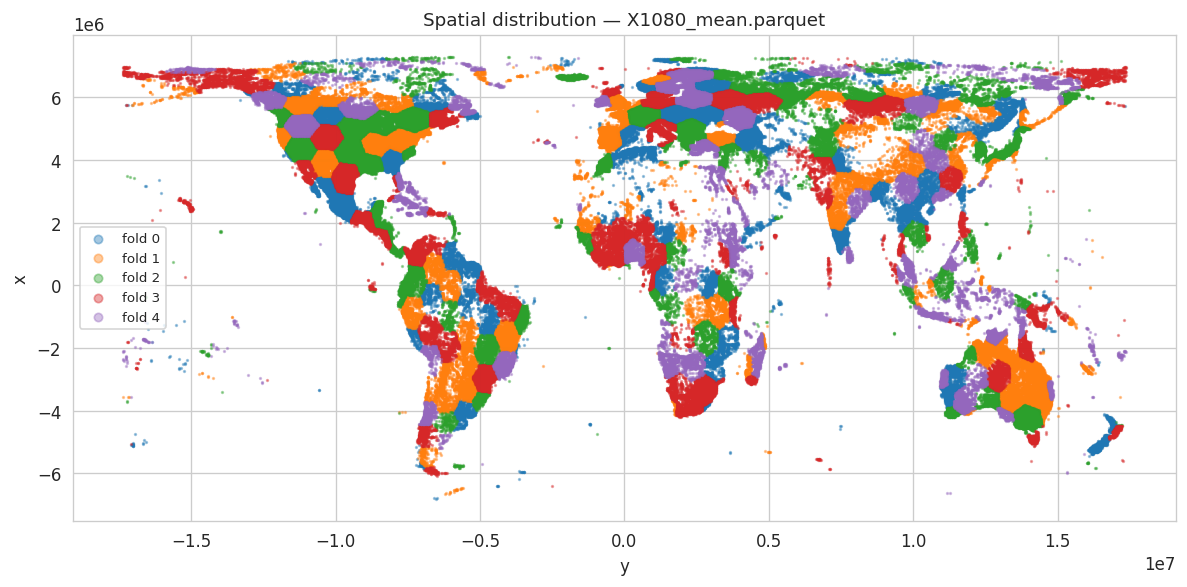

In [18]:
# ── Check if spatial coordinates are present ────────────────────────────────
coord_cols = [
    c
    for c in df_skcv.columns
    if any(k in c.lower() for k in ["lat", "lon", "x", "y", "coord", "geo"])
]
print(f"Potential coordinate columns: {coord_cols}")

# If coordinates exist, plot the spatial distribution of folds
if len(coord_cols) >= 2:
    lat_col = coord_cols[0]
    lon_col = coord_cols[1]
    fig, ax = plt.subplots(figsize=(10, 5))
    if fold_cols:
        for fold_val, grp in df_skcv.groupby(fold_cols[0]):
            ax.scatter(
                grp[lat_col], grp[lon_col], s=1, alpha=0.4, label=f"fold {fold_val}"
            )
        ax.legend(markerscale=5, fontsize=8)
    else:
        ax.scatter(
            df_skcv[lon_col], df_skcv[lat_col], s=1, alpha=0.3, color="steelblue"
        )
    ax.set_title(f"Spatial distribution — {os.path.basename(example_parquet)}")
    ax.set_xlabel(lon_col)
    ax.set_ylabel(lat_col)
    plt.tight_layout()
    plt.show()

In [19]:
# ── Check all parquet files have same structure ──────────────────────────────
print("Checking shape consistency across all parquet files...")
for f in skcv_files:
    df_tmp = pd.read_parquet(f)
    print(
        f"  {os.path.basename(f):50s}  shape={df_tmp.shape}  cols={df_tmp.columns.tolist()}"
    )

Checking shape consistency across all parquet files...
  X1080_mean.parquet                                  shape=(130527, 3)  cols=['x', 'y', 'fold']
  X138_mean.parquet                                   shape=(130558, 3)  cols=['x', 'y', 'fold']
  X13_mean.parquet                                    shape=(130229, 3)  cols=['x', 'y', 'fold']
  X144_mean.parquet                                   shape=(131318, 3)  cols=['x', 'y', 'fold']
  X145_mean.parquet                                   shape=(131489, 3)  cols=['x', 'y', 'fold']
  X146_mean.parquet                                   shape=(130722, 3)  cols=['x', 'y', 'fold']
  X14_mean.parquet                                    shape=(130489, 3)  cols=['x', 'y', 'fold']
  X15_mean.parquet                                    shape=(130174, 3)  cols=['x', 'y', 'fold']
  X163_mean.parquet                                   shape=(130655, 3)  cols=['x', 'y', 'fold']
  X169_mean.parquet                                   shape=(129297, 3) 

---
## 6. EO Data — Canopy Height

In [20]:
canopy_files = sorted(glob.glob(os.path.join(PATHS["canopy"], "*.tif")))
print(f"Canopy height files: {len(canopy_files)}")
for f in canopy_files:
    print(f"  {os.path.basename(f)}")

Canopy height files: 2
  ETH_GlobalCanopyHeightSD_2020_v1.tif
  ETH_GlobalCanopyHeight_2020_v1.tif


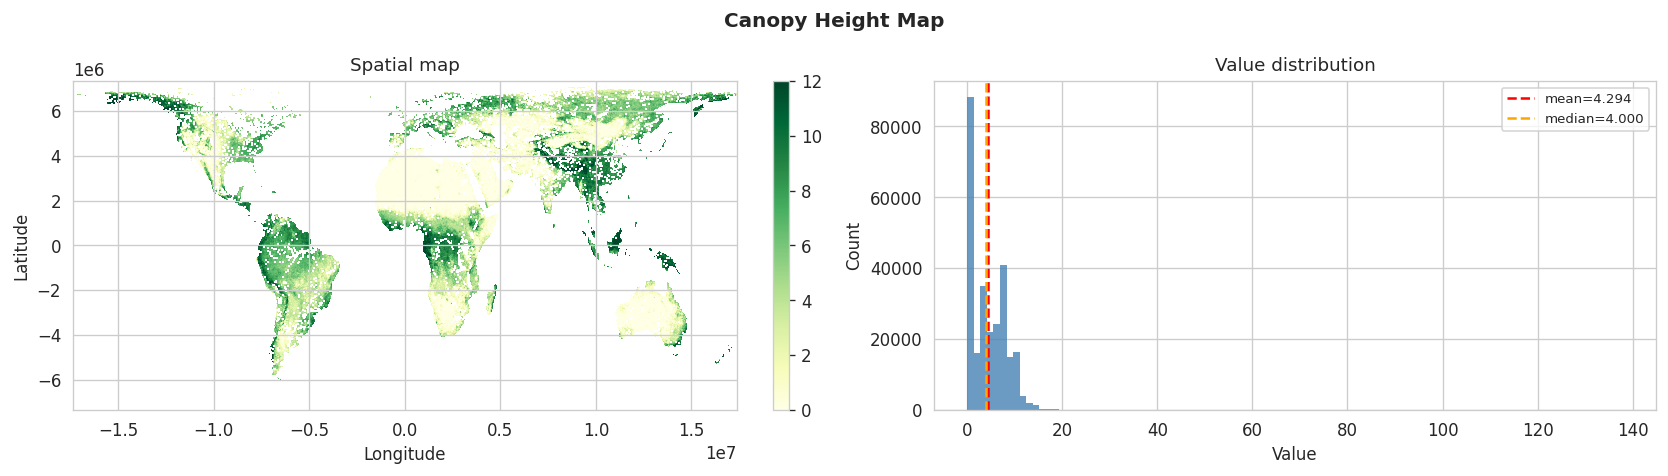

  Shape: (668, 1578) | Valid px: 265,160 | Min: 0.0000 | Max: 138.0000 | Mean: 4.2942 | Std: 3.7647


In [21]:
plot_tif(canopy_files[0], title="Canopy Height Map", cmap="YlGn")

---
## 7. EO Data — MODIS (Bands 1–5 + NDVI, 12 months)

In [22]:
modis_files = sorted(glob.glob(os.path.join(PATHS["modis"], "*.tif")))
print(f"MODIS TIF files found: {len(modis_files)}")
for f in modis_files:
    print(f"  {os.path.basename(f)}")

MODIS TIF files found: 72
  sur_refl_b01_2001-2024_m10_mean.tif
  sur_refl_b01_2001-2024_m11_mean.tif
  sur_refl_b01_2001-2024_m12_mean.tif
  sur_refl_b01_2001-2024_m1_mean.tif
  sur_refl_b01_2001-2024_m2_mean.tif
  sur_refl_b01_2001-2024_m3_mean.tif
  sur_refl_b01_2001-2024_m4_mean.tif
  sur_refl_b01_2001-2024_m5_mean.tif
  sur_refl_b01_2001-2024_m6_mean.tif
  sur_refl_b01_2001-2024_m7_mean.tif
  sur_refl_b01_2001-2024_m8_mean.tif
  sur_refl_b01_2001-2024_m9_mean.tif
  sur_refl_b02_2001-2024_m10_mean.tif
  sur_refl_b02_2001-2024_m11_mean.tif
  sur_refl_b02_2001-2024_m12_mean.tif
  sur_refl_b02_2001-2024_m1_mean.tif
  sur_refl_b02_2001-2024_m2_mean.tif
  sur_refl_b02_2001-2024_m3_mean.tif
  sur_refl_b02_2001-2024_m4_mean.tif
  sur_refl_b02_2001-2024_m5_mean.tif
  sur_refl_b02_2001-2024_m6_mean.tif
  sur_refl_b02_2001-2024_m7_mean.tif
  sur_refl_b02_2001-2024_m8_mean.tif
  sur_refl_b02_2001-2024_m9_mean.tif
  sur_refl_b03_2001-2024_m10_mean.tif
  sur_refl_b03_2001-2024_m11_mean.tif
  su

In [23]:
pd.set_option("display.max_rows", None)

# Summary stats for all MODIS files
modis_summary = summarise_folder(PATHS["modis"])
modis_summary[["file", "min", "max", "mean", "std", "n_valid", "n_nodata"]]

Found 72 files in modis


,file,min,max,mean,std,n_valid,n_nodata
0,sur_refl_b01_2001-2024_m10_mean.tif,0.0,10000.0,1639.644165,1549.378174,1054104,0
1,sur_refl_b01_2001-2024_m11_mean.tif,0.0,10000.0,1721.475586,1454.089111,1054104,0
2,sur_refl_b01_2001-2024_m12_mean.tif,0.0,10000.0,1842.822021,1681.265869,1054104,0
3,sur_refl_b01_2001-2024_m1_mean.tif,0.0,10000.0,2103.122559,1913.684814,1054104,0
4,sur_refl_b01_2001-2024_m2_mean.tif,0.0,10000.0,2491.766357,2221.790771,1054104,0
5,sur_refl_b01_2001-2024_m3_mean.tif,0.0,10000.0,2552.985352,2398.586426,1054104,0
6,sur_refl_b01_2001-2024_m4_mean.tif,0.0,10000.0,2280.457764,2339.687988,1054104,0
7,sur_refl_b01_2001-2024_m5_mean.tif,29.0,10000.0,1876.229370,2053.395508,1054104,0
8,sur_refl_b01_2001-2024_m6_mean.tif,25.0,10000.0,1448.404663,1568.533081,1054104,0
9,sur_refl_b01_2001-2024_m7_mean.tif,0.0,10000.0,1307.475830,1433.156738,1054104,0


In [24]:
# ── Parse MODIS filenames to identify band and month ─────────────────────────
modis_df = pd.DataFrame({"filepath": modis_files})
modis_df["filename"] = modis_df["filepath"].apply(os.path.basename)
modis_df.head(10)

,filepath,filename
0,/scratch3/plant-traits-v2/data/22km/eo_data/mo...,sur_refl_b01_2001-2024_m10_mean.tif
1,/scratch3/plant-traits-v2/data/22km/eo_data/mo...,sur_refl_b01_2001-2024_m11_mean.tif
2,/scratch3/plant-traits-v2/data/22km/eo_data/mo...,sur_refl_b01_2001-2024_m12_mean.tif
3,/scratch3/plant-traits-v2/data/22km/eo_data/mo...,sur_refl_b01_2001-2024_m1_mean.tif
4,/scratch3/plant-traits-v2/data/22km/eo_data/mo...,sur_refl_b01_2001-2024_m2_mean.tif
5,/scratch3/plant-traits-v2/data/22km/eo_data/mo...,sur_refl_b01_2001-2024_m3_mean.tif
6,/scratch3/plant-traits-v2/data/22km/eo_data/mo...,sur_refl_b01_2001-2024_m4_mean.tif
7,/scratch3/plant-traits-v2/data/22km/eo_data/mo...,sur_refl_b01_2001-2024_m5_mean.tif
8,/scratch3/plant-traits-v2/data/22km/eo_data/mo...,sur_refl_b01_2001-2024_m6_mean.tif
9,/scratch3/plant-traits-v2/data/22km/eo_data/mo...,sur_refl_b01_2001-2024_m7_mean.tif


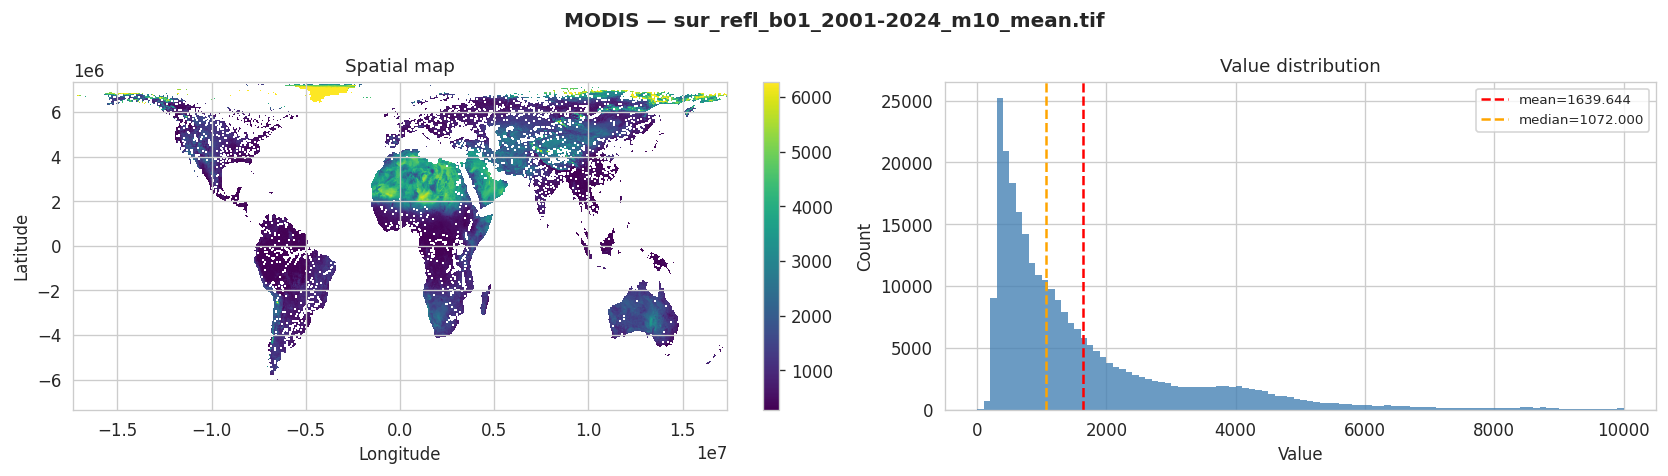

  Shape: (668, 1578) | Valid px: 269,853 | Min: 0.0000 | Max: 10000.0000 | Mean: 1639.6442 | Std: 1549.3781


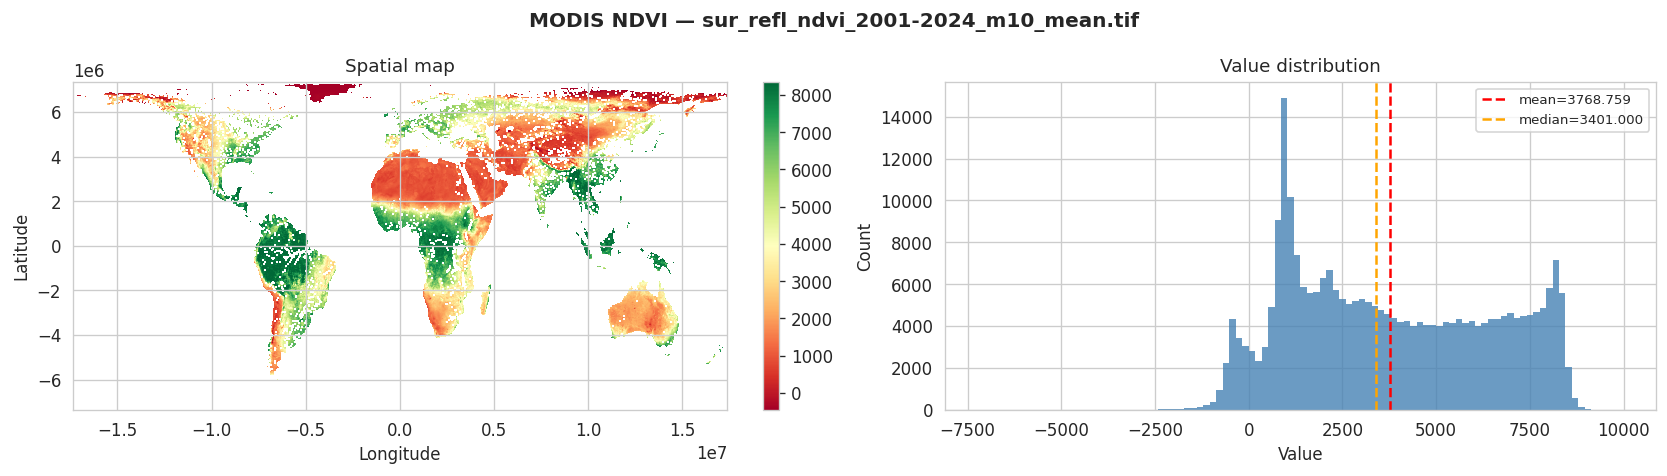

  Shape: (668, 1578) | Valid px: 269,853 | Min: -7242.0000 | Max: 10000.0000 | Mean: 3768.7585 | Std: 2675.9402


In [25]:
example_modis = modis_files[0]
plot_tif(example_modis, title=f"MODIS — {os.path.basename(example_modis)}")

ndvi_files = [f for f in modis_files if "ndvi" in os.path.basename(f).lower()]
if ndvi_files:
    plot_tif(
        ndvi_files[0],
        title=f"MODIS NDVI — {os.path.basename(ndvi_files[0])}",
        cmap="RdYlGn",
    )

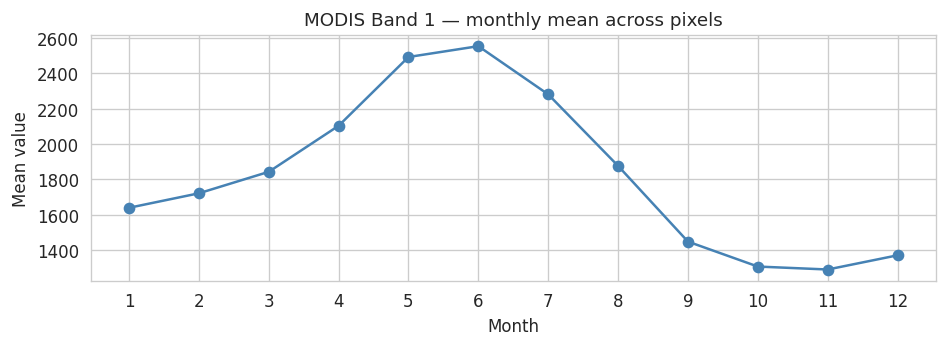

In [26]:
# ── MODIS: check seasonal variation for one band across 12 months ───────────
band1_files = sorted([f for f in modis_files if "b01" in os.path.basename(f).lower()])
if not band1_files:
    print(
        "No band1 files found — adjust the filter string below to match your filenames"
    )
    print("Available files:", [os.path.basename(f) for f in modis_files[:6]])
else:
    monthly_means = []
    for f in band1_files:
        with rasterio.open(f) as src:
            data = src.read(1).astype(np.float32)
            nd = src.nodata
        if nd is not None:
            data[data == nd] = np.nan
        monthly_means.append(np.nanmean(data))

    plt.figure(figsize=(8, 3))
    plt.plot(range(1, len(band1_files) + 1), monthly_means, "o-", color="steelblue")
    plt.xlabel("Month")
    plt.ylabel("Mean value")
    plt.title("MODIS Band 1 — monthly mean across pixels")
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

---
## 8. EO Data — SoilGrids

In [27]:
soil_files = sorted(glob.glob(os.path.join(PATHS["soil"], "*.tif")))
print(f"SoilGrids TIF files found: {len(soil_files)}")
for f in soil_files:
    print(f"  {os.path.basename(f)}")

SoilGrids TIF files found: 61
  bdod_0-5cm_mean.tif
  bdod_100-200cm_mean.tif
  bdod_15-30cm_mean.tif
  bdod_30-60cm_mean.tif
  bdod_5-15cm_mean.tif
  bdod_60-100cm_mean.tif
  cec_0-5cm_mean.tif
  cec_100-200cm_mean.tif
  cec_15-30cm_mean.tif
  cec_30-60cm_mean.tif
  cec_5-15cm_mean.tif
  cec_60-100cm_mean.tif
  cfvo_0-5cm_mean.tif
  cfvo_100-200cm_mean.tif
  cfvo_15-30cm_mean.tif
  cfvo_30-60cm_mean.tif
  cfvo_5-15cm_mean.tif
  cfvo_60-100cm_mean.tif
  clay_0-5cm_mean.tif
  clay_100-200cm_mean.tif
  clay_15-30cm_mean.tif
  clay_30-60cm_mean.tif
  clay_5-15cm_mean.tif
  clay_60-100cm_mean.tif
  nitrogen_0-5cm_mean.tif
  nitrogen_100-200cm_mean.tif
  nitrogen_15-30cm_mean.tif
  nitrogen_30-60cm_mean.tif
  nitrogen_5-15cm_mean.tif
  nitrogen_60-100cm_mean.tif
  ocd_0-5cm_mean.tif
  ocd_100-200cm_mean.tif
  ocd_15-30cm_mean.tif
  ocd_30-60cm_mean.tif
  ocd_5-15cm_mean.tif
  ocd_60-100cm_mean.tif
  ocs_0-30cm_mean.tif
  phh2o_0-5cm_mean.tif
  phh2o_100-200cm_mean.tif
  phh2o_15-30cm_mean.t

In [28]:
# Summary stats for all soil files
soil_summary = summarise_folder(PATHS["soil"])
soil_summary[["file", "min", "max", "mean", "std", "n_valid", "n_nodata"]]

Found 61 files in soilgrids


,file,min,max,mean,std,n_valid,n_nodata
0,bdod_0-5cm_mean.tif,25.0,179.0,118.222748,26.025253,1054104,0
1,bdod_100-200cm_mean.tif,28.0,194.0,143.813492,12.308856,1054104,0
2,bdod_15-30cm_mean.tif,25.0,186.0,133.331711,14.253480,1054104,0
3,bdod_30-60cm_mean.tif,26.0,189.0,139.782425,12.622040,1054104,0
4,bdod_5-15cm_mean.tif,25.0,180.0,127.240601,18.004162,1054104,0
5,bdod_60-100cm_mean.tif,28.0,192.0,142.734634,12.355381,1054104,0
6,cec_0-5cm_mean.tif,17.0,895.0,250.127594,121.514053,1054104,0
7,cec_100-200cm_mean.tif,15.0,947.0,192.498718,84.091896,1054104,0
8,cec_15-30cm_mean.tif,17.0,977.0,203.372574,86.108360,1054104,0
9,cec_30-60cm_mean.tif,16.0,1003.0,196.535385,83.012161,1054104,0


In [29]:
# ── Parse soil filenames to identify property and depth ──────────────────────
soil_df = pd.DataFrame({"filepath": soil_files})
soil_df["filename"] = soil_df["filepath"].apply(os.path.basename)


# Try to parse property name and depth from filename
def parse_soil_name(fname):
    parts = fname.replace(".tif", "").split("_")
    return pd.Series(
        {
            "property": parts[0] if len(parts) > 0 else fname,
            "depth": parts[1] if len(parts) > 1 else "unknown",
            "stat": parts[2] if len(parts) > 2 else "unknown",
        }
    )


soil_df = pd.concat([soil_df, soil_df["filename"].apply(parse_soil_name)], axis=1)
print("Unique soil properties:", soil_df["property"].unique().tolist())
print("Unique depths:", soil_df["depth"].unique().tolist())
soil_df[["filename", "property", "depth", "stat"]]

Unique soil properties: ['bdod', 'cec', 'cfvo', 'clay', 'nitrogen', 'ocd', 'ocs', 'phh2o', 'sand', 'silt', 'soc']
Unique depths: ['0-5cm', '100-200cm', '15-30cm', '30-60cm', '5-15cm', '60-100cm', '0-30cm']


,filename,property,depth,stat
0,bdod_0-5cm_mean.tif,bdod,0-5cm,mean
1,bdod_100-200cm_mean.tif,bdod,100-200cm,mean
2,bdod_15-30cm_mean.tif,bdod,15-30cm,mean
3,bdod_30-60cm_mean.tif,bdod,30-60cm,mean
4,bdod_5-15cm_mean.tif,bdod,5-15cm,mean
5,bdod_60-100cm_mean.tif,bdod,60-100cm,mean
6,cec_0-5cm_mean.tif,cec,0-5cm,mean
7,cec_100-200cm_mean.tif,cec,100-200cm,mean
8,cec_15-30cm_mean.tif,cec,15-30cm,mean
9,cec_30-60cm_mean.tif,cec,30-60cm,mean


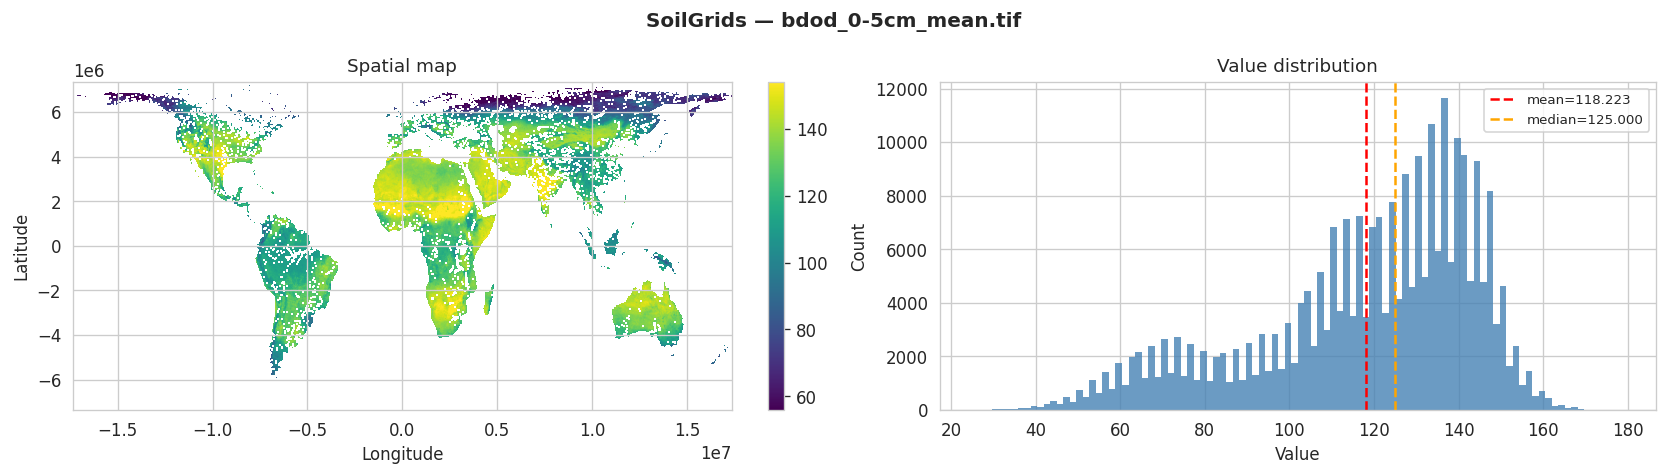

  Shape: (668, 1578) | Valid px: 264,310 | Min: 25.0000 | Max: 179.0000 | Mean: 118.2227 | Std: 26.0253


In [30]:
# ── Inspect one soil property at one depth ───────────────────────────────────
example_soil = soil_files[0]
plot_tif(example_soil, title=f"SoilGrids — {os.path.basename(example_soil)}")

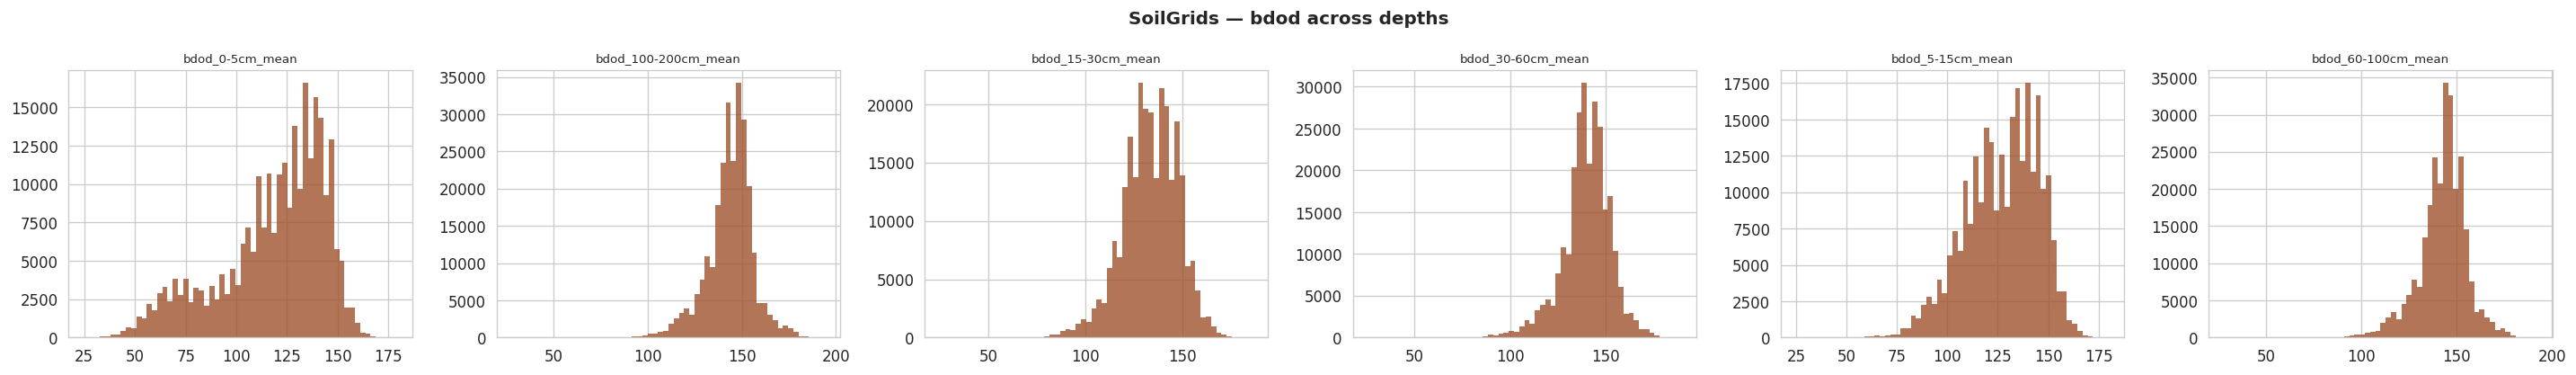

In [31]:
# ── Check depth variation for one soil property ──────────────────────────────
first_prop = soil_df["property"].iloc[0]
prop_files = soil_df[soil_df["property"] == first_prop]["filepath"].tolist()

if len(prop_files) > 1:
    n = len(prop_files)
    fig, axes = plt.subplots(1, n, figsize=(n * 4, 3.5))
    if n == 1:
        axes = [axes]
    for ax, f in zip(axes, prop_files):
        with rasterio.open(f) as src:
            data = src.read(1).astype(np.float32)
            nd = src.nodata
        if nd is not None:
            data[data == nd] = np.nan
        valid = data[~np.isnan(data)]
        ax.hist(valid, bins=60, color="sienna", edgecolor="none", alpha=0.8)
        ax.set_title(os.path.basename(f).replace(".tif", ""), fontsize=8)
    fig.suptitle(f"SoilGrids — {first_prop} across depths", fontweight="bold")
    plt.tight_layout()
    plt.show()

---
## 9. EO Data — VODCA (Vegetation Optical Depth)

In [32]:
vodca_files = sorted(glob.glob(os.path.join(PATHS["vodca"], "*.tif")))
print(f"VODCA TIF files found: {len(vodca_files)}")
for f in vodca_files:
    print(f"  {os.path.basename(f)}")

VODCA TIF files found: 9
  vodca_c-band_mean.tif
  vodca_c-band_p5.tif
  vodca_c-band_p95.tif
  vodca_k-band_mean.tif
  vodca_k-band_p5.tif
  vodca_k-band_p95.tif
  vodca_x-band_mean.tif
  vodca_x-band_p5.tif
  vodca_x-band_p95.tif


In [33]:
# Summary stats for all VODCA files
vodca_summary = summarise_folder(PATHS["vodca"])
vodca_summary[["file", "min", "max", "mean", "std", "n_valid", "n_nodata"]]

Found 9 files in vodca


,file,min,max,mean,std,n_valid,n_nodata
0,vodca_c-band_mean.tif,-32767.0,32767.0,-6076.676758,14647.124023,255724,798380
1,vodca_c-band_p5.tif,-32767.0,32767.0,-7457.867676,16498.164062,255724,798380
2,vodca_c-band_p95.tif,-32767.0,32767.0,-5459.733398,13038.177734,255724,798380
3,vodca_k-band_mean.tif,-32767.0,32767.0,9288.980469,18495.025391,257430,796674
4,vodca_k-band_p5.tif,-32767.0,32767.0,2361.571777,17590.300781,257430,796674
5,vodca_k-band_p95.tif,-32767.0,32767.0,15289.614258,18065.294922,257430,796674
6,vodca_x-band_mean.tif,-32767.0,32767.0,-4824.286621,14718.033203,257378,796726
7,vodca_x-band_p5.tif,-32767.0,32767.0,-7148.183105,15641.897461,257378,796726
8,vodca_x-band_p95.tif,-32767.0,32767.0,-2863.685791,13767.739258,257378,796726


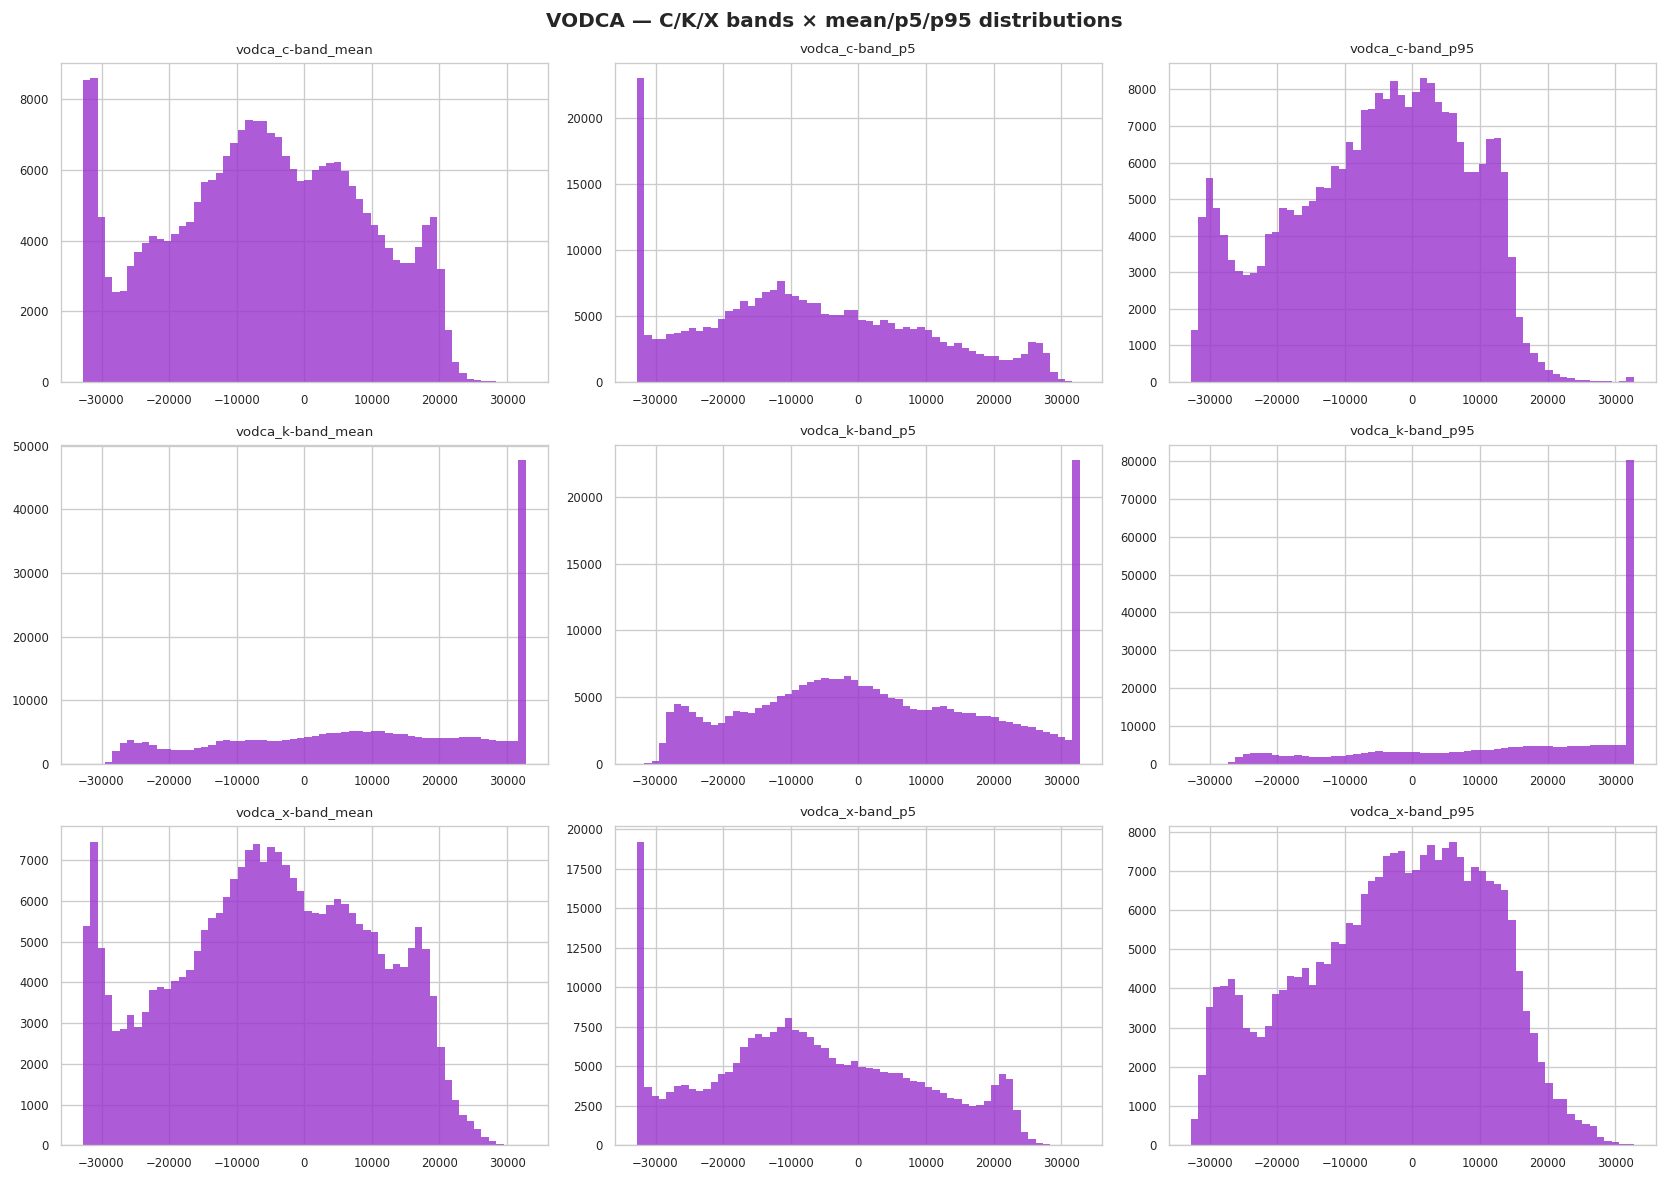

In [34]:
# ── Plot all 9 VODCA files ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, fpath in enumerate(vodca_files):
    with rasterio.open(fpath) as src:
        data = src.read(1).astype(np.float32)
        nd = src.nodata
    if nd is not None:
        data[data == nd] = np.nan
    valid = data[~np.isnan(data)]
    axes[i].hist(valid, bins=60, color="darkorchid", edgecolor="none", alpha=0.8)
    axes[i].set_title(os.path.basename(fpath).replace(".tif", ""), fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, 9):
    axes[j].set_visible(False)

fig.suptitle(
    "VODCA — C/K/X bands × mean/p5/p95 distributions", fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

---
## 10. EO Data — WorldClim 2.1 Bioclimatic Variables

In [35]:
wc_files = sorted(glob.glob(os.path.join(PATHS["worldclim"], "*.tif")))
print(f"WorldClim TIF files found: {len(wc_files)}")
for f in wc_files:
    print(f"  {os.path.basename(f)}")

# Reference guide for the bioclim variables in this dataset
bio_info = {
    "bio1": "Annual Mean Temperature (°C × 10)",
    "bio4": "Temperature Seasonality (std × 100)",
    "bio7": "Temperature Annual Range (°C × 10)",
    "bio12": "Annual Precipitation (mm)",
    "bio13": "Precipitation of Wettest Month (mm)",
    "bio14": "Precipitation of Driest Month (mm)",
    "bio15": "Precipitation Seasonality (CV)",
}
print("\nVariable descriptions:")
for k, v in bio_info.items():
    print(f"  {k}: {v}")

WorldClim TIF files found: 6
  wc2.1_30s_bio_1.tif
  wc2.1_30s_bio_12.tif
  wc2.1_30s_bio_13-14.tif
  wc2.1_30s_bio_15.tif
  wc2.1_30s_bio_4.tif
  wc2.1_30s_bio_7.tif

Variable descriptions:
  bio1: Annual Mean Temperature (°C × 10)
  bio4: Temperature Seasonality (std × 100)
  bio7: Temperature Annual Range (°C × 10)
  bio12: Annual Precipitation (mm)
  bio13: Precipitation of Wettest Month (mm)
  bio14: Precipitation of Driest Month (mm)
  bio15: Precipitation Seasonality (CV)


In [36]:
# Summary stats for all WorldClim files
wc_summary = summarise_folder(PATHS["worldclim"])
wc_summary[["file", "min", "max", "mean", "std", "n_valid", "n_nodata"]]

Found 6 files in worldclim


,file,min,max,mean,std,n_valid,n_nodata
0,wc2.1_30s_bio_1.tif,-32767.0,32767.000000,12800.231445,14721.967773,269565,784539
1,wc2.1_30s_bio_12.tif,-32767.0,32767.000000,-26439.560547,5956.228027,269565,784539
2,wc2.1_30s_bio_13-14.tif,0.0,2560.000488,113.493736,112.602585,1054104,0
3,wc2.1_30s_bio_15.tif,-32767.0,32767.000000,-13099.568359,10217.706055,269565,784539
4,wc2.1_30s_bio_4.tif,-32767.0,32767.000000,-13172.258789,13985.875000,269565,784539
5,wc2.1_30s_bio_7.tif,-32767.0,32767.000000,-4678.241699,12302.674805,269565,784539


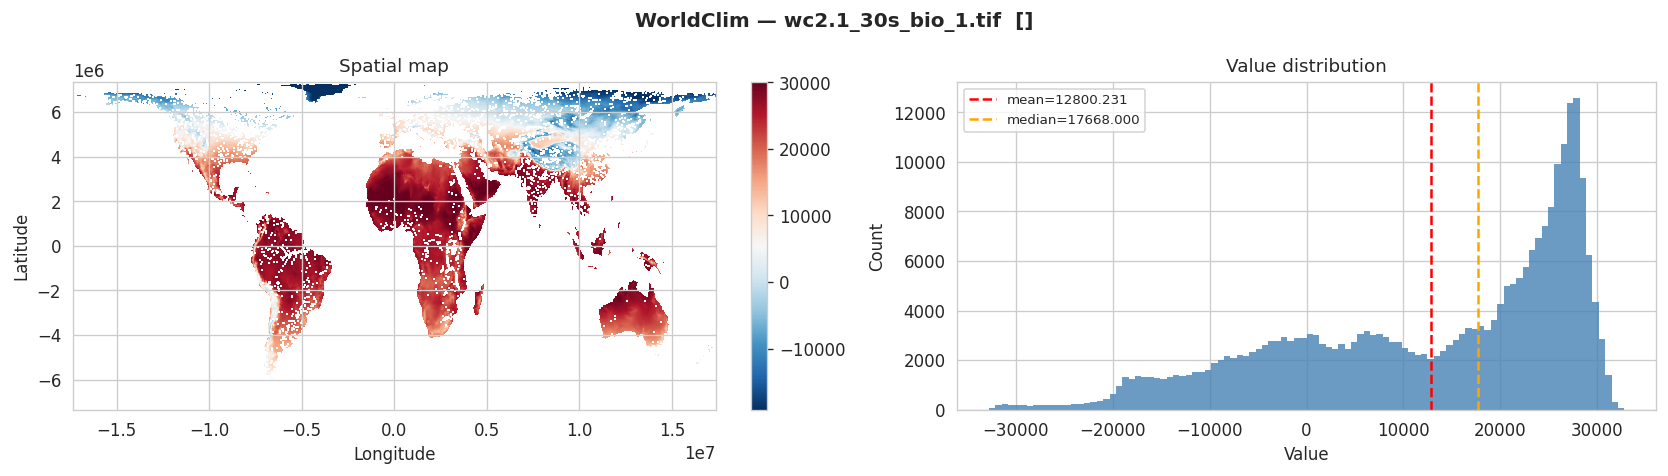

  Shape: (668, 1578) | Valid px: 269,565 | Min: -32767.0000 | Max: 32767.0000 | Mean: 12800.2314 | Std: 14721.9678


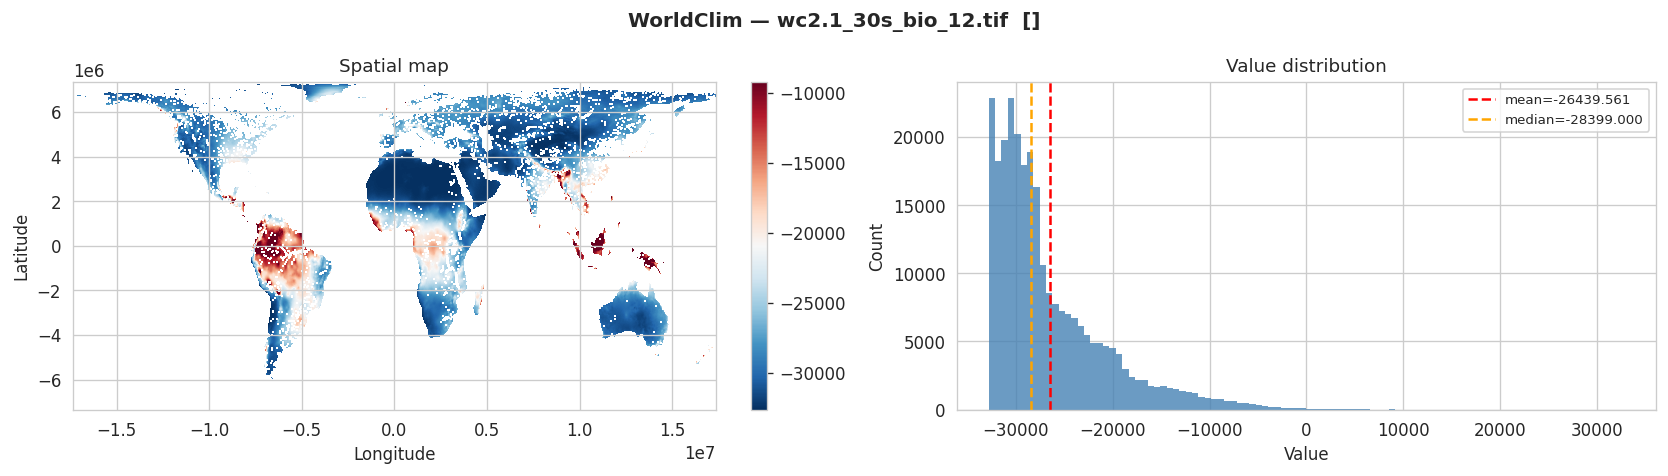

  Shape: (668, 1578) | Valid px: 269,565 | Min: -32767.0000 | Max: 32767.0000 | Mean: -26439.5605 | Std: 5956.2280


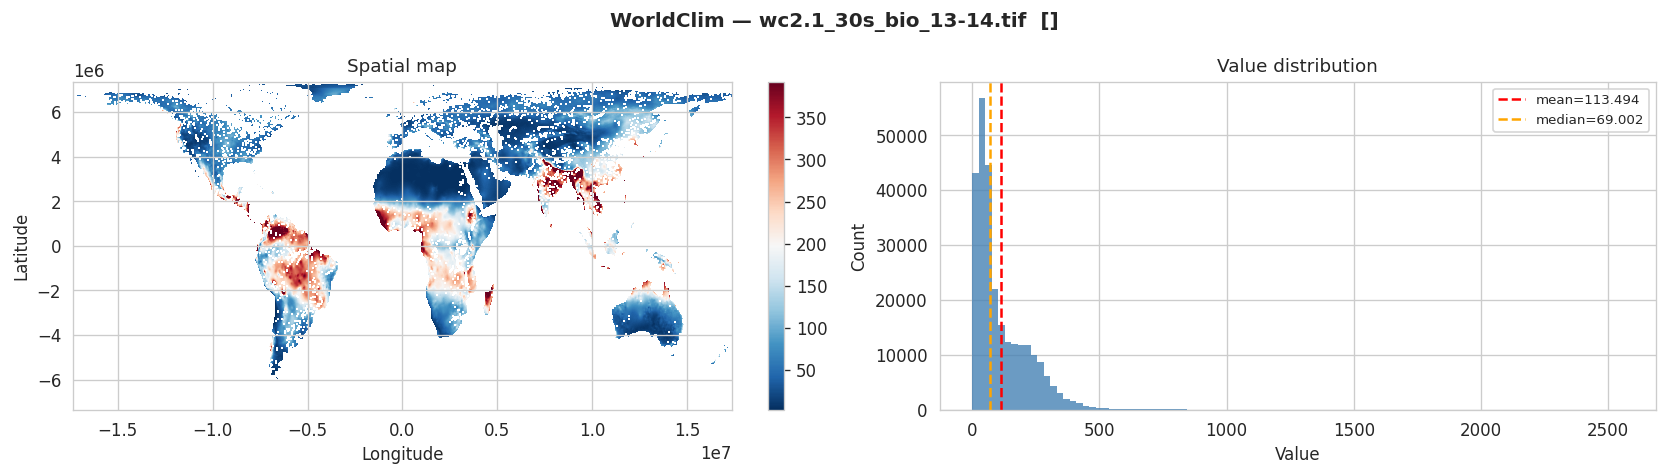

  Shape: (668, 1578) | Valid px: 269,565 | Min: 0.0000 | Max: 2560.0005 | Mean: 113.4937 | Std: 112.6026


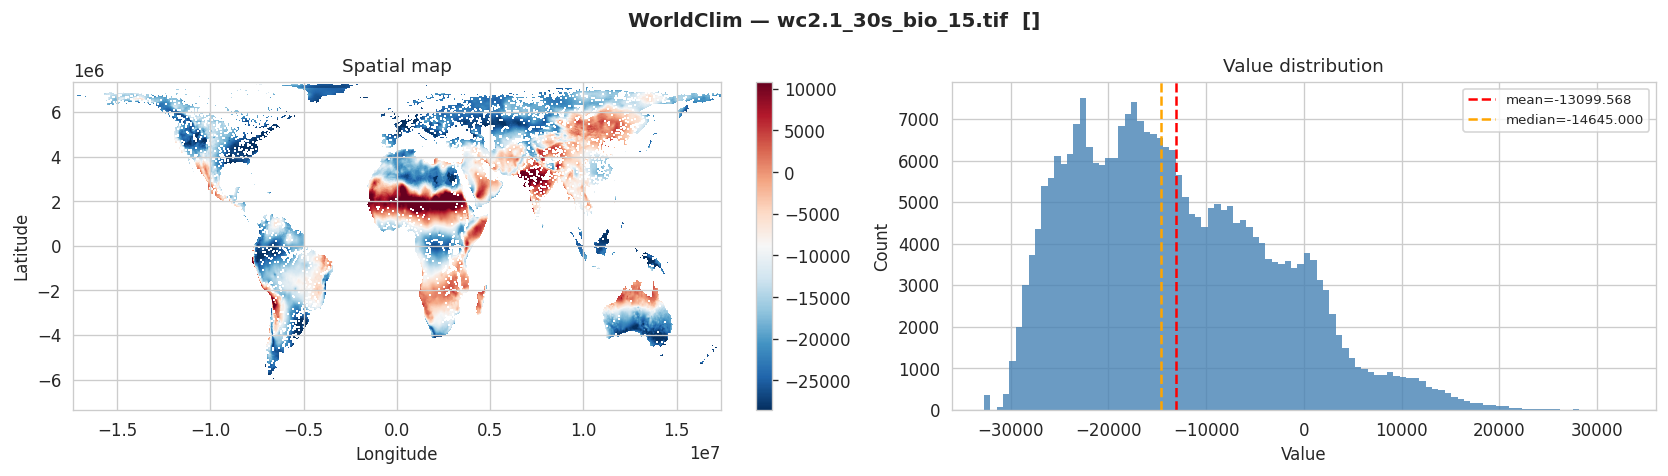

  Shape: (668, 1578) | Valid px: 269,565 | Min: -32767.0000 | Max: 32767.0000 | Mean: -13099.5684 | Std: 10217.7061


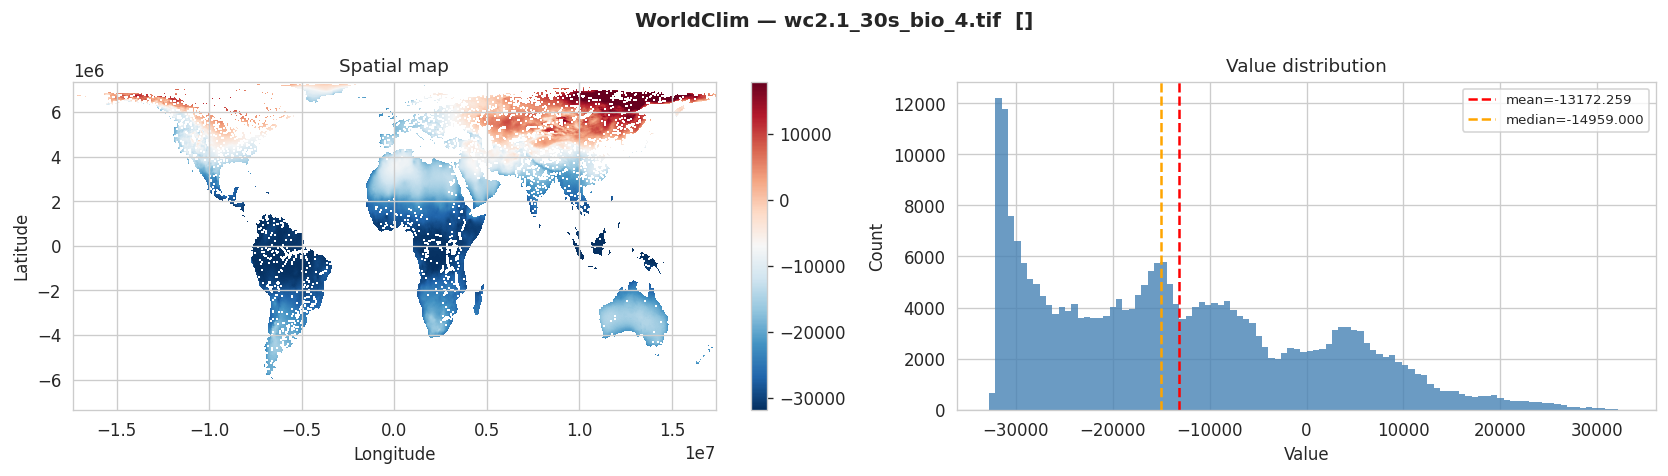

  Shape: (668, 1578) | Valid px: 269,565 | Min: -32767.0000 | Max: 32767.0000 | Mean: -13172.2588 | Std: 13985.8750


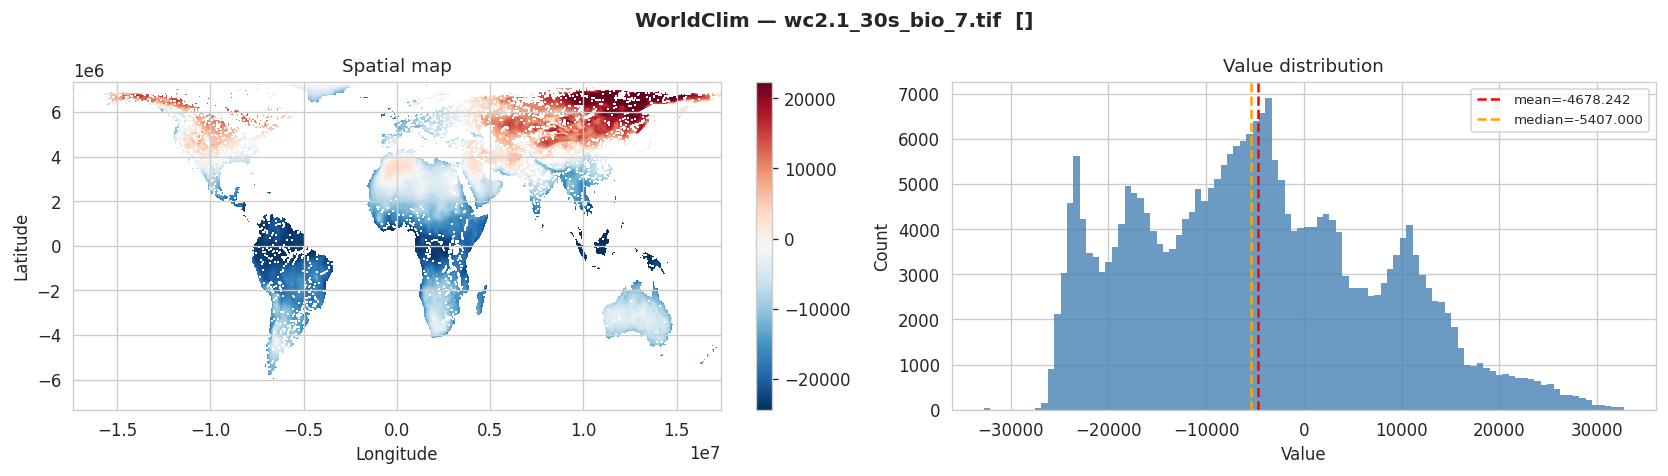

  Shape: (668, 1578) | Valid px: 269,565 | Min: -32767.0000 | Max: 32767.0000 | Mean: -4678.2417 | Std: 12302.6748


In [37]:
# ── Plot all WorldClim variables: map + histogram ────────────────────────────
for fpath in wc_files:
    fname = os.path.basename(fpath)
    # Determine variable name for the title
    bio_key = next((k for k in bio_info if k in fname.lower()), fname)
    desc = bio_info.get(bio_key, "")
    plot_tif(fpath, title=f"WorldClim — {fname}  [{desc}]", cmap="RdBu_r")

---
## 11. Cross-Dataset Consistency Check

Confirm all datasets share the same CRS, resolution, and extent (they should all be at 22km resolution and aligned).

In [38]:
# Pick one representative file from each dataset
representative_files = {
    "gbif": gbif_files[0],
    "splot": splot_files[0],
    "canopy": canopy_files[0],
    "modis": modis_files[0],
    "soil": soil_files[0],
    "vodca": vodca_files[0],
    "worldclim": wc_files[0],
}

rows = []
for name, fpath in representative_files.items():
    with rasterio.open(fpath) as src:
        rows.append(
            {
                "dataset": name,
                "file": os.path.basename(fpath),
                "width": src.width,
                "height": src.height,
                "crs": str(src.crs),
                "res_x": round(src.transform.a, 6),
                "res_y": round(abs(src.transform.e), 6),
                "left": round(src.bounds.left, 3),
                "right": round(src.bounds.right, 3),
                "bottom": round(src.bounds.bottom, 3),
                "top": round(src.bounds.top, 3),
            }
        )

consistency_df = pd.DataFrame(rows)
consistency_df

,dataset,file,width,height,crs,res_x,res_y,left,right,bottom,top
0,gbif,X1080.tif,1578,668,EPSG:6933,22012.079145,21982.68095,-1.736753e+07,1.736753e+07,-7342215.437,7342215.437
1,splot,X1080.tif,1578,668,EPSG:6933,22012.079145,21982.68095,-1.736753e+07,1.736753e+07,-7342215.437,7342215.437
2,canopy,ETH_GlobalCanopyHeightSD_2020_v1.tif,1578,668,EPSG:6933,22012.079145,21982.68095,-1.736753e+07,1.736753e+07,-7342215.437,7342215.437
3,modis,sur_refl_b01_2001-2024_m10_mean.tif,1578,668,EPSG:6933,22012.079145,21982.68095,-1.736753e+07,1.736753e+07,-7342215.437,7342215.437
4,soil,bdod_0-5cm_mean.tif,1578,668,EPSG:6933,22012.079145,21982.68095,-1.736753e+07,1.736753e+07,-7342215.437,7342215.437
5,vodca,vodca_c-band_mean.tif,1578,668,EPSG:6933,22012.079145,21982.68095,-1.736753e+07,1.736753e+07,-7342215.437,7342215.437
6,worldclim,wc2.1_30s_bio_1.tif,1578,668,EPSG:6933,22012.079145,21982.68095,-1.736753e+07,1.736753e+07,-7342215.437,7342215.437


In [39]:
# Highlight any mismatches
ref = consistency_df.iloc[0]
for col in ["width", "height", "crs", "res_x", "res_y"]:
    mismatches = consistency_df[consistency_df[col] != ref[col]]["dataset"].tolist()
    if mismatches:
        print(f"⚠️  {col} mismatch in: {mismatches}")
    else:
        print(f"✅ {col}: all consistent ({ref[col]})")

✅ width: all consistent (1578)
✅ height: all consistent (668)
✅ crs: all consistent (EPSG:6933)
✅ res_x: all consistent (22012.079145)
✅ res_y: all consistent (21982.68095)
